
## **Evaluasi Efektivitas Kampanye Promosi Digital E-Commerce**



# **1. Tahap Pengumpulan Data (Data Collection)**

### **1.1 Identifikasi Jenis Data dalam Dataset**

Dataset yang digunakan dalam penelitian ini terdiri dari tiga jenis data utama, yaitu:

**1. Data Pelanggan (Customer Data)**

Data ini berisi informasi karakteristik pelanggan, meliputi:

*   customer_id
*   gender
*   age
*   city
*   cutomer_rating

**2. Data Transaksi (Transaction Data)**

Data transaksi menggambarkan aktivitas pembelian pelanggan, yang terdiri dari:

*   total_transaction
*   transaction_count
*   last_purchase_days

**3. Data Promosi (Promotion Data)**

Data promosi menunjukkan respons pelanggan terhadap kampanye promosi digital, meliputi:

*   promo_type

*   promo_click
*   promo_conversion

### **1.2 Tujuan Penggunaan Setiap Kelompok Data**

* **Data pelanggan** digunakan untuk memahami karakteristik dan segmentasi pelanggan berdasarkan demografi dan tingkat kepuasan.

* **Data transaksi** digunakan untuk mengukur nilai ekonomi pelanggan, intensitas pembelian, serta tingkat loyalitas.

* **Data promosi** digunakan untuk mengevaluasi efektivitas kampanye promosi digital berdasarkan interaksi dan konversi pelanggan.

### **1.3 Variabel Utama untuk Analisis Efektivitas Promosi**

Variabel utama yang relevan dalam analisis efektivitas promosi adalah:

promo_click sebagai indikator ketertarikan pelanggan,

promo_conversion sebagai indikator keberhasilan promosi,

promo_type untuk membandingkan efektivitas jenis promosi,

transaction_count dan total_transaction untuk melihat dampak promosi terhadap transaksi,

last_purchase_days untuk mengukur pengaruh loyalitas pelanggan terhadap konversi.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [ ]:
df = pd.read_excel("Dataset_eCommerce.xlsx")

print("Ukuran dataset:", df.shape)
df.head()

Ukuran dataset: (1000, 11)


,customer_id,gender,age,city,total_transaction,transaction_count,promo_type,promo_click,promo_conversion,last_purchase_days,customer_rating
0,C0001,F,38,Medan,6769324.0,14,Cashback,0.0,1,80,2.7
1,C0002,F,46,Bandung,9623591.0,12,FreeShipping,0.0,0,41,NaN
2,C0003,F,23,Semarang,5475045.0,8,Discount,0.0,0,132,4.8
3,C0004,F,54,Bandung,7594176.0,3,Cashback,0.0,0,2,4.5
4,C0005,M,18,Surabaya,5918952.0,13,Cashback,0.0,0,149,2.8


# **2. Data Understanding**

Tahap data understanding bertujuan untuk memahami struktur, karakteristik,
dan kualitas dataset sebelum dilakukan analisis lanjutan.

Pada tahap ini dilakukan:
1. Penelaahan struktur dataset
2. Identifikasi jumlah data dan variabel
3. Identifikasi tipe data
4. Pemeriksaan permasalahan awal seperti missing value

Langkah ini penting untuk memastikan bahwa data layak dianalisis dan
meminimalkan kesalahan pada tahap pemodelan.


In [ ]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         1000 non-null   object 
 1   gender              1000 non-null   object 
 2   age                 1000 non-null   int64  
 3   city                1000 non-null   object 
 4   total_transaction   950 non-null    float64
 5   transaction_count   1000 non-null   int64  
 6   promo_type          1000 non-null   object 
 7   promo_click         912 non-null    float64
 8   promo_conversion    1000 non-null   int64  
 9   last_purchase_days  1000 non-null   int64  
 10  customer_rating     920 non-null    float64
dtypes: float64(3), int64(4), object(4)
memory usage: 86.1+ KB


,0
customer_id,0
gender,0
age,0
city,0
total_transaction,50
transaction_count,0
promo_type,0
promo_click,88
promo_conversion,0
last_purchase_days,0


Hasil Analisis:

* Jumlah data: 1000 baris

* Jumlah variabel: 11 kolom

Tipe Data:

* Numerik: age, total_transaction, transaction_count, promo_click, promo_conversion, last_purchase_days, customer_rating

* Kategorikal: customer_id, gender, city, promo_type

| Variabel          | Missing Value |
| ----------------- | ------------- |
| total_transaction | 50            |
| promo_click       | 88            |
| customer_rating   | 80            |


#**3. Data Cleaning**

Tahap data cleaning dilakukan untuk meningkatkan kualitas data dengan
mengatasi permasalahan data yang ditemukan pada tahap sebelumnya.

Proses pembersihan data yang dilakukan meliputi:
1. Penanganan missing value pada variabel numerik
2. Validasi kembali kelengkapan dataset setelah pembersihan

Missing value diisi menggunakan nilai median karena metode ini
lebih stabil terhadap outlier dibandingkan mean.


In [ ]:
df_clean = df.copy()

df_clean['total_transaction'].fillna(df_clean['total_transaction'].median(), inplace=True)
df_clean['promo_click'].fillna(0, inplace=True)
df_clean['customer_rating'].fillna(df_clean['customer_rating'].median(), inplace=True)

df_clean.isnull().sum()

/tmp/ipython-input-758020360.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['total_transaction'].fillna(df_clean['total_transaction'].median(), inplace=True)
/tmp/ipython-input-758020360.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[c

,0
customer_id,0
gender,0
age,0
city,0
total_transaction,0
transaction_count,0
promo_type,0
promo_click,0
promo_conversion,0
last_purchase_days,0


#**4. Data Construction / Exploratory Data Analysis (EDA)**

Tahap Exploratory Data Analysis (EDA) bertujuan untuk menggali pola,
hubungan, dan karakteristik data melalui analisis statistik
dan visualisasi.

Analisis EDA yang dilakukan meliputi:
- Distribusi karakteristik pelanggan
- Hubungan antara promosi dan konversi
- Analisis korelasi antar variabel numerik

Hasil EDA digunakan sebagai dasar dalam pemilihan metode pemodelan
dan interpretasi bisnis.


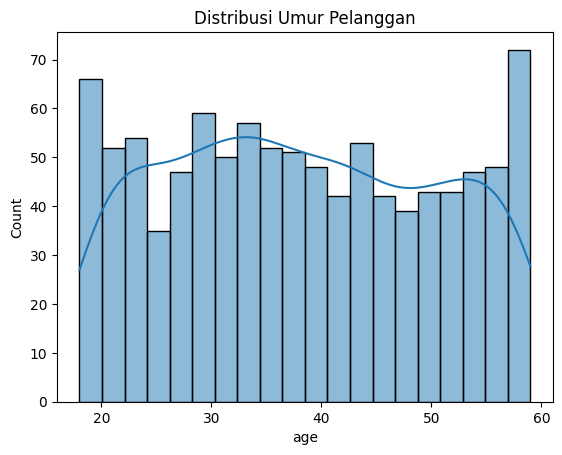

In [ ]:
plt.figure()
sns.histplot(df_clean['age'], bins=20, kde=True)
plt.title("Distribusi Umur Pelanggan")
plt.show()

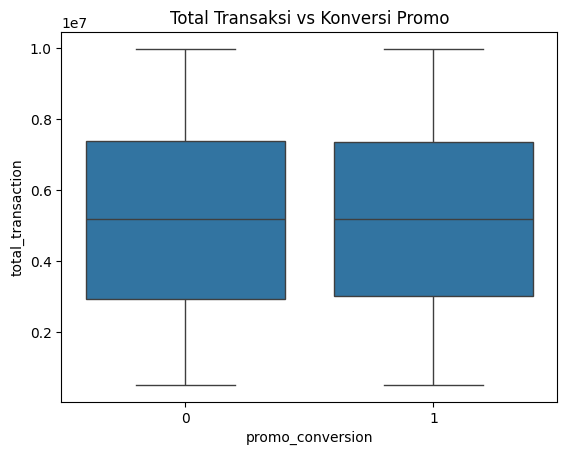

In [ ]:
plt.figure()
sns.boxplot(x='promo_conversion', y='total_transaction', data=df_clean)
plt.title("Total Transaksi vs Konversi Promo")
plt.show()

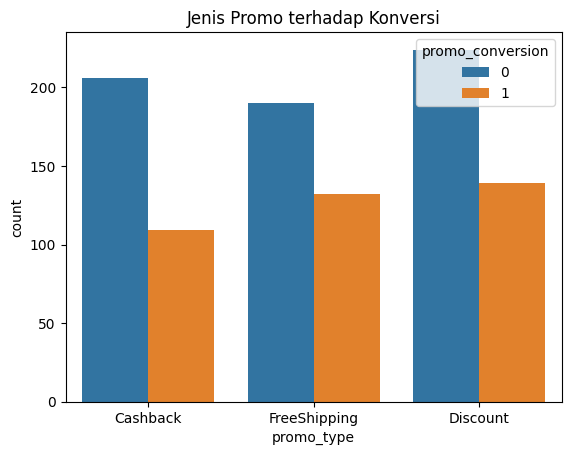

In [ ]:
plt.figure()
sns.countplot(x='promo_type', hue='promo_conversion', data=df_clean)
plt.title("Jenis Promo terhadap Konversi")
plt.show()

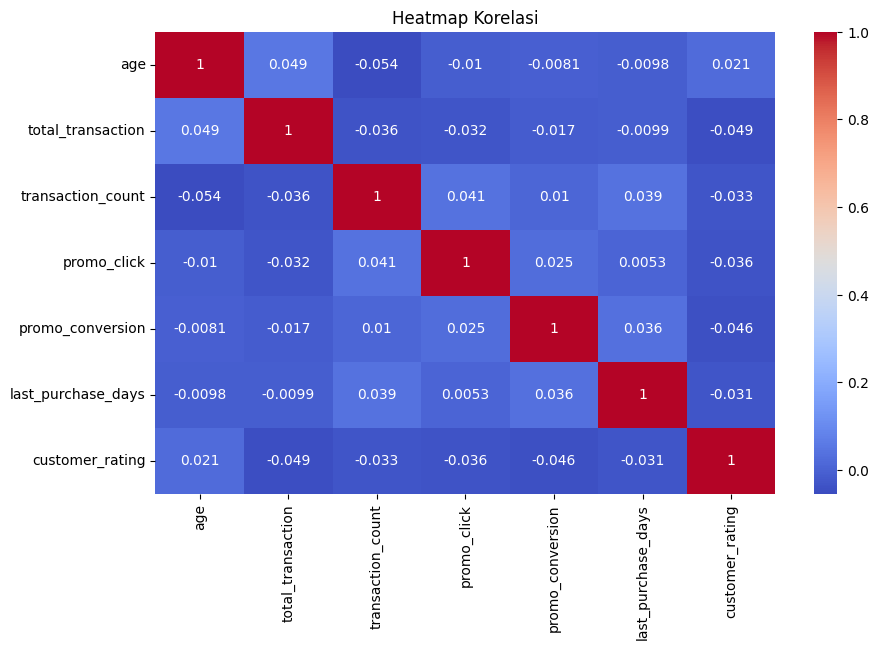

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df_clean.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Heatmap Korelasi")
plt.show()

# **5. Data Modeling**

Tahap pemodelan data bertujuan untuk membangun model analitik
yang dapat memprediksi keberhasilan kampanye promosi digital.

Permasalahan ini termasuk dalam klasifikasi biner, yaitu
memprediksi apakah pelanggan akan melakukan konversi promosi
atau tidak.

Model yang digunakan adalah Logistic Regression karena:
- Sesuai untuk klasifikasi biner
- Mudah diinterpretasikan
- Banyak digunakan dalam analisis pemasaran dan bisnis


In [ ]:
le = LabelEncoder()
df_clean['gender'] = le.fit_transform(df_clean['gender'])
df_clean['promo_type'] = le.fit_transform(df_clean['promo_type'])

In [ ]:
X = df_clean[['age', 'transaction_count', 'promo_click', 'last_purchase_days']]
y = df_clean['promo_conversion']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]


# **Evaluasi Model**

Evaluasi model dilakukan untuk mengukur kinerja model klasifikasi
dalam memprediksi konversi promosi.

Metode evaluasi yang digunakan meliputi:
- Classification Report
- Confusion Matrix
- ROC-AUC Curve

Hasil evaluasi digunakan untuk menilai kemampuan model
dalam membedakan pelanggan yang berpotensi melakukan konversi.


In [ ]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.66      1.00      0.79       131
           1       0.00      0.00      0.00        69

    accuracy                           0.66       200
   macro avg       0.33      0.50      0.40       200
weighted avg       0.43      0.66      0.52       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
confusion_matrix(y_test, y_pred)


array([[131,   0],
       [ 69,   0]])

ROC-AUC Score: 0.4739462329903751


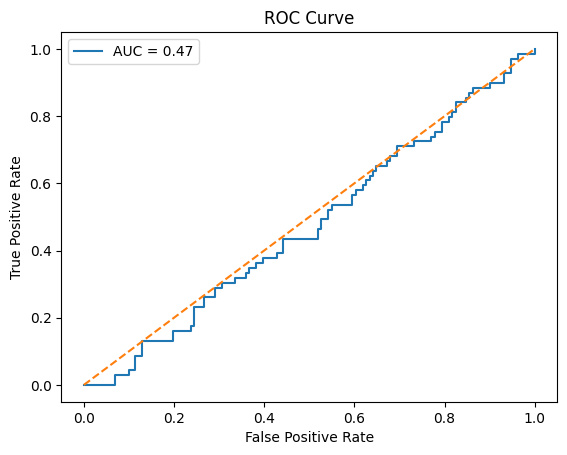

In [ ]:
auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", auc)

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


# **Segmentasi Pelanggan (Clustering)**

Selain klasifikasi, dilakukan clustering pelanggan menggunakan
metode K-Means untuk mengelompokkan pelanggan berdasarkan
karakteristik transaksi.

Hasil clustering digunakan untuk mendukung strategi promosi
yang lebih terarah dan personal.


In [ ]:
coef_df = pd.DataFrame({
    'Variabel': X.columns,
    'Koefisien': model.coef_[0]
}).sort_values(by='Koefisien', ascending=False)

coef_df


,Variabel,Koefisien
2,promo_click,0.062618
1,transaction_count,0.007193
3,last_purchase_days,0.000731
0,age,-0.006514


In [ ]:
scaler = StandardScaler()
X_cluster = scaler.fit_transform(
    df_clean[['age','transaction_count','total_transaction','last_purchase_days']]
)

kmeans = KMeans(n_clusters=3, random_state=42)
df_clean['cluster'] = kmeans.fit_predict(X_cluster)


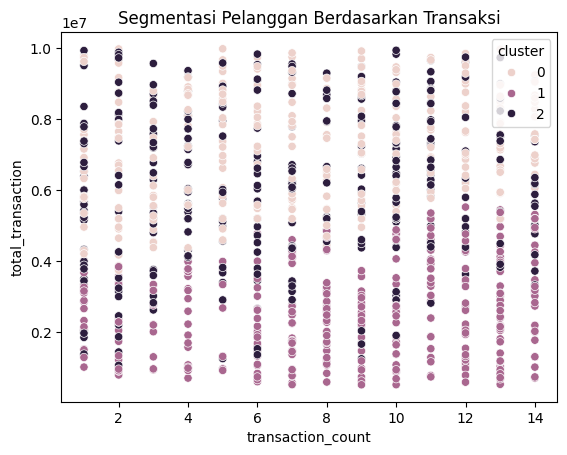

In [ ]:
plt.figure()
sns.scatterplot(
    x=df_clean['transaction_count'],
    y=df_clean['total_transaction'],
    hue=df_clean['cluster']
)
plt.title("Segmentasi Pelanggan Berdasarkan Transaksi")
plt.show()


### **Interpretasi Hasil Model dan Implikasi Bisnis**

Berdasarkan hasil pemodelan data yang telah dilakukan menggunakan
Logistic Regression dan Clustering, model mampu mengidentifikasi
pelanggan yang memiliki probabilitas tinggi untuk merespons promosi
digital secara positif.

####**1. Membantu Manajemen**
Hasil model memberikan gambaran berbasis data mengenai karakteristik
pelanggan yang cenderung melakukan konversi setelah menerima promosi.
Informasi ini membantu manajemen dalam:
- Menentukan target pelanggan yang lebih tepat
- Mengalokasikan anggaran promosi secara efisien
- Mengurangi pemborosan biaya pada segmen pelanggan yang tidak responsif

####**2. Meningkatkan Efektivitas Promosi**
Dengan mengetahui pola pelanggan yang responsif terhadap promosi,
perusahaan dapat:
- Menyusun strategi promosi yang lebih personal dan relevan
- Meningkatkan tingkat konversi promosi
- Mengoptimalkan waktu dan jenis promosi yang diberikan kepada pelanggan

#### **3. Mendukung Pengambilan Keputusan Strategis**
Hasil analisis dan pemodelan data mendukung pengambilan keputusan
strategis perusahaan, seperti:
- Penentuan strategi pemasaran jangka panjang
- Segmentasi pelanggan berbasis perilaku transaksi
- Perancangan kampanye promosi yang lebih tepat sasaran
berdasarkan insight data historis pelanggan


# **Kesimpulan**

Berdasarkan hasil analisis data dan pemodelan yang dilakukan,
dapat disimpulkan bahwa efektivitas kampanye promosi digital
dipengaruhi oleh interaksi pelanggan terhadap promosi dan
perilaku transaksi sebelumnya.

Hasil analisis ini dapat digunakan oleh manajemen untuk
meningkatkan efektivitas promosi, mengoptimalkan biaya pemasaran,
dan mendukung pengambilan keputusan strategis berbasis data.
